In [1]:
#Read in data
import pickle

# Open the .pkl file in read-binary mode
with open('/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/finetuned/cell_annot_subset_test_metrics_dict.pkl', 'rb') as file:
    all_metrics_test = pickle.load(file)

# Open the .pkl file in read-binary mode
# with open('/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/finetuned/260129_geneformer_cellClassifier_cell_annot_subset/cell_annot_subset_eval_metrics_dict.pkl', 'rb') as file:
#     all_metrics_test = pickle.load(file)


In [18]:
conf_mat = all_metrics_test["conf_matrix"]

In [19]:
conf_mat = conf_mat[conf_mat.index != "pDC"]
conf_mat = conf_mat[conf_mat.columns[conf_mat.columns != "pDC"]]

In [20]:
conf_mat

,Monocytes,B cells,Platelet,mDC,T cells,NK cells
Monocytes,799,0,0,1,0,0
B cells,0,800,0,0,0,0
Platelet,1,0,111,0,0,0
mDC,0,0,0,361,0,0
T cells,0,0,0,0,798,2
NK cells,0,0,0,0,3,797


In [21]:
import pandas as pd
metrics = pd.DataFrame(index=conf_mat.index, columns=["Precision", "Recall", "F1", "Accuracy"])

for cls in conf_mat.columns:
    tp = conf_mat.loc[cls, cls]  # True Positives
    fp = conf_mat[cls].sum() - tp  # False Positives
    fn = conf_mat.loc[cls].sum() - tp  # False Negatives
    tn = conf_mat.values.sum() - (tp + fp + fn)  # True Negatives

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / conf_mat.values.sum()

    metrics.loc[cls] = [precision, recall, f1, accuracy]

# Convert all to float and round for readability
metrics = metrics.astype(float).round(3)

# Sort by F1 score (descending order)
metrics = metrics.sort_values(by="F1", ascending=False)

print(metrics)

           Precision  Recall     F1  Accuracy
B cells        1.000   1.000  1.000     1.000
Monocytes      0.999   0.999  0.999     0.999
mDC            0.997   1.000  0.999     1.000
T cells        0.996   0.998  0.997     0.999
NK cells       0.997   0.996  0.997     0.999
Platelet       1.000   0.991  0.996     1.000


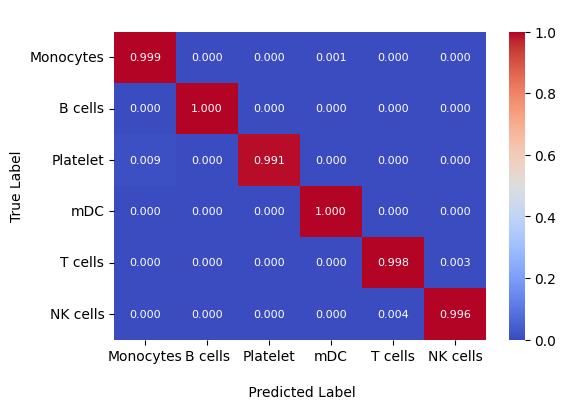

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Normalize the confusion matrix to proportions
conf_matrix_row_normalized = conf_mat.div(conf_mat.sum(axis=1), axis=0)

# Create the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_row_normalized, 
    annot=True,                # Display values in the heatmap
    fmt=".3f",                 # Format of annotations (2 decimal places)
    cmap="coolwarm",           # Color map
    annot_kws={"size": 8}      # Reduce font size of annotations
)
plt.title(" ", fontsize=13)
plt.xlabel(" \n Predicted Label", fontsize=10)
plt.ylabel("True Label", fontsize=10)
#plt.savefig(f"{output_dir}/cell_annot_subset_test_proportions.png")
plt.show()